In [19]:
import fastf1
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import random
import matplotlib.pyplot as plt


# --- 1. 설정 및 데이터 로드 ---
EVENT = 'Japanese Grand Prix'
YEAR = 2023
SESSION = 'R'
CACHE_DIR = '../fastf1_cache'
DIST_POINTS = 1000  # 리샘플링 포인트 수

fastf1.Cache.enable_cache(CACHE_DIR)
session = fastf1.get_session(YEAR, EVENT, SESSION)
session.load()

print(f"Session Loaded: {YEAR} {EVENT} - {SESSION}")

core           INFO 	Loading data for Japanese Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 00:00.076000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '44', '55', '63', '14', '31', '10', '40', '2

Session Loaded: 2023 Japanese Grand Prix - R


In [20]:
# --- 2. [핵심] Race Preprocessing for Dataset B & C ---

# 전체 드라이버의 랩 데이터를 가져옵니다.
race_laps = session.laps.pick_wo_box().pick_track_status('1').pick_accurate().copy()

# 필요 없는 컬럼 제거 및 정렬 준비 (가벼운 처리를 위해)
# 같은 LapNumber 내에서 Position 순으로 정렬 (1위, 2위, 3위... 순서대로 줄세우기)
race_laps = race_laps.sort_values(by=['LapNumber', 'Position'])

# 1. GapToAhead: 내 시간 - 앞차 시간 (같은 랩)
# 그룹화: LapNumber (각 랩 별로 계산해야 함)
race_laps['GapToAhead'] = race_laps.groupby('LapNumber')['Time'].diff().dt.total_seconds()

# 2. GapToBehind: 뒷차 시간 - 내 시간
# diff(-1)은 (현재 - 다음)이므로 부호를 바꿈. 혹은 shift(-1) 사용
race_laps['GapToBehind'] = race_laps.groupby('LapNumber')['Time'].diff(-1).dt.total_seconds().abs()

# NaN 처리: 
# 1위는 앞차가 없으므로 GapToAhead = 무한대(Clean) 혹은 매우 큰 값 처리
# 꼴등은 뒷차가 없으므로 GapToBehind = 무한대 처리
race_laps['GapToAhead'] = race_laps['GapToAhead'].fillna(999.0)
race_laps['GapToBehind'] = race_laps['GapToBehind'].fillna(999.0)

# --- Dataset Separation Logic ---

# Battle Condition (Dirty Air): 앞뒤 1.5초 이내
battle_mask = (race_laps['GapToAhead'] <= 1.5) | (race_laps['GapToBehind'] <= 1.5)

# Dataset C: Battle (Dirty Air)
ds_c_laps = race_laps[battle_mask].copy()
ds_c_laps['Scenario'] = 'C_Battle'

# Dataset B: Clean Air (Pure Pace) -> 학습용(Training)
ds_b_laps = race_laps[~battle_mask].copy()
ds_b_laps['Scenario'] = 'B_Clean'

print(f"Total Laps: {len(race_laps)}")
print(f"Dataset B (Clean Air) Laps: {len(ds_b_laps)} (Training Target)")
print(f"Dataset C (Battle) Laps: {len(ds_c_laps)} (Test/Analysis Target)")




Total Laps: 686
Dataset B (Clean Air) Laps: 461 (Training Target)
Dataset C (Battle) Laps: 225 (Test/Analysis Target)


In [21]:
# --- 3. Telemetry Processing Functions (기존 로직 유지) ---

def calculate_slip_delta(telemetry_df):
    # (이전과 동일한 로직: Gear Ratio 기반 SLIP_DELTA 계산)
    baseline_data = telemetry_df[telemetry_df['nGear'] > 0]
    gear_ratios = {}
    for gear in baseline_data['nGear'].unique():
        gear_slice = baseline_data[baseline_data['nGear'] == gear]
        valid_rpm = gear_slice[gear_slice['RPM'] > 0]
        if len(valid_rpm) > 0:
            gear_ratios[gear] = (valid_rpm['Speed'] / valid_rpm['RPM']).mean()
            
    telemetry_df['Estimated_Speed'] = telemetry_df.apply(
        lambda row: row['RPM'] * gear_ratios.get(row['nGear'], 0), axis=1
    )
    telemetry_df['SLIP_DELTA'] = telemetry_df['Estimated_Speed'] - telemetry_df['Speed']
    return telemetry_df

def process_laps_to_tensor(laps_df, dist_points=200):
    """
    필터링된 Laps DataFrame을 받아 Telemetry를 추출하고 Resampling하여 통합 DataFrame 반환
    """
    processed_laps = []
    
    # 진행 상황 표시를 위해 enumerate 사용
    print(f"Processing {len(laps_df)} laps...")
    
    for i, (idx, lap) in enumerate(laps_df.iterrows()):
        try:
            # 1. Telemetry 로드
            telemetry = lap.get_telemetry()
            
            # 2. Distance Interpolation (Resampling)
            total_dist = telemetry['Distance'].max()
            new_dist = np.linspace(0, total_dist, dist_points)
            
            cols_to_interp = ['Speed', 'RPM', 'Throttle', 'nGear', 'DRS']
            new_data = {'Distance': new_dist}
            
            for col in cols_to_interp:
                new_data[col] = np.interp(new_dist, telemetry['Distance'], telemetry[col])
            
            new_data['Brake'] = np.interp(new_dist, telemetry['Distance'], telemetry['Brake'].astype(float))
            
            resampled_df = pd.DataFrame(new_data)
            
            # 3. Feature Engineering
            resampled_df = calculate_slip_delta(resampled_df)
            
            # 4. Context Features
            resampled_df['TyreLife'] = lap['TyreLife']
            resampled_df['LapNumber'] = lap['LapNumber']
            resampled_df['Compound_SOFT'] = 1 if lap['Compound'] == 'SOFT' else 0
            resampled_df['Compound_MEDIUM'] = 1 if lap['Compound'] == 'MEDIUM' else 0
            resampled_df['Compound_HARD'] = 1 if lap['Compound'] == 'HARD' else 0
            resampled_df['Driver'] = lap['Driver'] # 나중에 분석용으로 드라이버 태그 추가
            
            processed_laps.append(resampled_df)
            
        except Exception as e:
            continue
            
    if not processed_laps:
        return None
        
    return pd.concat(processed_laps, ignore_index=True)

In [23]:
# --- 4. 데이터 생성 및 스케일링 ---

# Dataset B (Clean Air) 만 처리하여 학습 데이터로 사용
# (Top 10 드라이버만 필터링하고 싶다면 여기서 필터 추가 가능)
TARGET_DRIVERS = ['VER', 'NOR', 'PIA', 'LEC', 'HAM', 'SAI', 'RUS', 'ALO', 'OCO', 'GAS']
training_laps = ds_b_laps[ds_b_laps['Driver'].isin(TARGET_DRIVERS)]

print("Extracting Telemetry for Dataset B (Clean Air)...")
full_dataset_b = process_laps_to_tensor(training_laps, dist_points=DIST_POINTS)

# Feature Columns 정의
feature_cols = [
    'Speed', 'RPM', 'Throttle', 'Brake', 'nGear', 'DRS', 
    'SLIP_DELTA', 
    'TyreLife', 'LapNumber', 'Compound_SOFT', 'Compound_MEDIUM', 'Compound_HARD'
]

# Scaling
scaler = MinMaxScaler()
full_dataset_b[feature_cols] = scaler.fit_transform(full_dataset_b[feature_cols])

# Tensor 변환
num_samples = len(full_dataset_b) // DIST_POINTS
X_data = full_dataset_b[feature_cols].values[:num_samples * DIST_POINTS]
X_reshaped = X_data.reshape(num_samples, DIST_POINTS, len(feature_cols))

tensor_X = torch.FloatTensor(X_reshaped).to('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Training Tensor Shape: {tensor_X.shape}") 
# (Batch_Size, Sequence_Length, Num_Features)


Extracting Telemetry for Dataset B (Clean Air)...
Processing 295 laps...
Training Tensor Shape: torch.Size([295, 1000, 12])


In [24]:
import os

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # 멀티 GPU 사용 시
    torch.backends.cudnn.deterministic = True  # 연산 순서 고정 (속도 약간 느려짐)
    torch.backends.cudnn.benchmark = False     # 최적화 알고리즘 고정

SEED = 42
seed_everything(SEED)
print(f"Random Seed fixed to {SEED}")

Random Seed fixed to 42


In [25]:
# --- 2. 하이퍼파라미터 설정 (오버피팅 방지용 수정) ---
# 기존 128 -> 64 (또는 32)로 축소하여 모델 용량 제한
EMBEDDING_DIM = 128 
# Dropout 비율 설정 (0.2 = 20% 뉴런 비활성화)
DROPOUT_RATE = 0.2
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3

In [26]:
from torch.utils.data import DataLoader, TensorDataset, random_split

# --- 3. 데이터셋 분리 (Train / Validation) ---
# dataset 변수는 이전 단계에서 만들어진 TensorDataset이라고 가정합니다.
# 전체 데이터 중 80%는 학습, 20%는 검증에 사용
dataset = TensorDataset(tensor_X, tensor_X)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# 시드가 고정되었으므로 매번 똑같이 나뉩니다.

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Data Split -> Train: {len(train_dataset)}, Val: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Data Split -> Train: 236, Val: 59


Start Training...
Epoch [10/50] Train Loss: 0.039580 | Val Loss: 0.041361
Epoch [20/50] Train Loss: 0.035924 | Val Loss: 0.035665
Epoch [30/50] Train Loss: 0.033347 | Val Loss: 0.032775
Epoch [40/50] Train Loss: 0.032779 | Val Loss: 0.032399
Epoch [50/50] Train Loss: 0.032632 | Val Loss: 0.032431


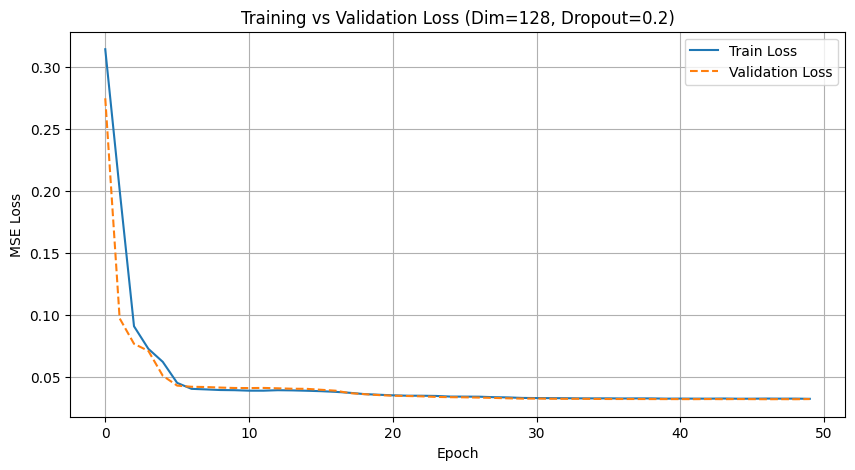

In [27]:

# --- 5. 모델 학습 (LSTM Autoencoder) ---
# (이전 코드와 동일, 데이터만 tensor_X로 사용)

# --- 4. 모델 정의 (Dropout 추가) ---
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64, dropout=0.0):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        
        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_size=n_features, 
            hidden_size=embedding_dim, 
            batch_first=True
        )
        
        # Dropout: Latent Vector에 노이즈를 주어 과적합 방지
        self.dropout = nn.Dropout(dropout)
        
        # Decoder
        self.decoder_lstm = nn.LSTM(
            input_size=embedding_dim, 
            hidden_size=embedding_dim, 
            batch_first=True
        )
        
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        # 1. Encoding
        _, (hidden, _) = self.encoder_lstm(x)
        # hidden[-1] shape: (Batch, Embedding_Dim)
        
        # 2. Bottleneck (Dropout 적용)
        # Latent Vector가 특정 패턴을 단순 암기하는 것을 방지
        hidden_state = self.dropout(hidden[-1])
        
        # 3. Repeat Vector (Bridge)
        # (Batch, 1, Dim) -> (Batch, Seq_Len, Dim)
        x_repeated = hidden_state.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        # 4. Decoding
        decoder_output, _ = self.decoder_lstm(x_repeated)
        
        # 5. Output Reconstruction
        x_reconstructed = self.output_layer(decoder_output)
        
        return x_reconstructed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMAutoencoder(seq_len=DIST_POINTS, n_features=len(feature_cols)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- 5. 학습 루프 (Validation Loss 모니터링) ---
train_losses = []
val_losses = []

print("Start Training...")

for epoch in range(NUM_EPOCHS):
    # [Train Mode] Dropout 활성화, Gradient 계산 함
    model.train() 
    epoch_train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # [Eval Mode] Dropout 비활성화, Gradient 계산 안 함 (순수 성능 평가)
    model.eval() 
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

# --- 6. 결과 시각화 ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss', linestyle='--')
plt.title(f'Training vs Validation Loss (Dim={EMBEDDING_DIM}, Dropout={DROPOUT_RATE})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# 1. 퀄리파잉 세션 로드
Q_SESSION = fastf1.get_session(YEAR, EVENT, 'Q')
Q_SESSION.load()

print(f"Qualifying Session Loaded: {YEAR} {EVENT}")

def prepare_quali_lap(driver, session, scaler, dist_points=1000):
    """
    특정 드라이버의 퀄리파잉 베스트 랩을 가져와 모델 입력 형태로 변환
    """
    # 드라이버의 가장 빠른 랩 선택
    try:
        # Pick Fastest Lap (가장 빠른 랩 하나만 분석)
        best_lap = session.laps.pick_driver(driver).pick_fastest()
    except:
        print(f"No data for {driver}")
        return None, None

    # --- Telemetry Processing (학습 때와 동일한 로직) ---
    telemetry = best_lap.get_telemetry()
    
    # 1. 거리 기반 리샘플링
    total_dist = telemetry['Distance'].max()
    new_dist = np.linspace(0, total_dist, dist_points)
    
    # 보간할 컬럼들
    cols_to_interp = ['Speed', 'RPM', 'Throttle', 'nGear', 'DRS']
    new_data = {'Distance': new_dist}
    
    for col in cols_to_interp:
        new_data[col] = np.interp(new_dist, telemetry['Distance'], telemetry[col])
    
    new_data['Brake'] = np.interp(new_dist, telemetry['Distance'], telemetry['Brake'].astype(float))
    
    df = pd.DataFrame(new_data)
    
    # 2. Feature Engineering: SLIP_DELTA
    # (주의: 기어비 Baseline은 레이스 데이터에서 구한 값을 쓰거나, 여기서 다시 구해도 되지만
    #  정밀함을 위해선 레이스 때 썼던 global gear_ratios를 쓰는 게 좋습니다.
    #  여기선 편의상 자체 계산합니다.)
    df = calculate_slip_delta(df) 
    
    # 3. Context Features (피처 차이 주의!)
    df['TyreLife'] = best_lap['TyreLife']
    df['LapNumber'] = best_lap['LapNumber']
    
    # Compound One-Hot Encoding (Quali는 주로 SOFT)
    # 만약 데이터가 비어있으면 SOFT로 가정하거나 예외처리
    compound = best_lap['Compound']
    df['Compound_SOFT'] = 1 if compound == 'SOFT' else 0
    df['Compound_MEDIUM'] = 1 if compound == 'MEDIUM' else 0
    df['Compound_HARD'] = 1 if compound == 'HARD' else 0
    
    # 학습 데이터와 컬럼 순서 정확히 일치시키기
    feature_cols = [
        'Speed', 'RPM', 'Throttle', 'Brake', 'nGear', 'DRS', 
        'SLIP_DELTA', 
        'TyreLife', 'LapNumber', 'Compound_SOFT', 'Compound_MEDIUM', 'Compound_HARD'
    ]
    
    # 4. Scaling (중요: 학습된 scaler 사용!)
    # scaler는 학습 코드에서 joblib으로 저장했거나 메모리에 있는 그 객체여야 함
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.transform(df[feature_cols])
    
    return df, df_scaled[feature_cols].values # 원본(시각화용), 스케일된 값(모델용)

# 예시: 베르스타펜(VER)의 퀄리파잉 랩 준비
driver_code = 'VER'
original_df, input_data = prepare_quali_lap(driver_code, Q_SESSION, scaler, dist_points=DIST_POINTS)

print(f"Quali Data Prepared for {driver_code}. Shape: {input_data.shape}")

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWa

Qualifying Session Loaded: 2023 Japanese Grand Prix
Quali Data Prepared for VER. Shape: (1000, 12)


In [31]:
# Tensor 변환
# (1, 1000, 12) 배치 차원 추가
input_tensor = torch.FloatTensor(input_data).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    reconstructed_tensor = model(input_tensor)
    
# 다시 numpy로 변환
reconstructed_data = reconstructed_tensor.squeeze(0).cpu().numpy()

# --- 분석: 어디가 가장 다를까? ---
# 1. 전체 MSE Loss (이 숫자가 클수록 레이스 페이스와 거리가 먼, 즉 공격적인 랩)
mse_loss = np.mean((input_data - reconstructed_data)**2)
print(f"Reconstruction Error (Anomaly Score): {mse_loss:.6f}")

# 2. 포인트별 에러 (트랙 어디서 무리했나?)
# 모든 피처에 대한 에러를 합쳐서 1차원 배열로 만듦
point_wise_loss = np.mean((input_data - reconstructed_data)**2, axis=1)

# 원본 데이터프레임에 에러 컬럼 추가
original_df['Anomaly_Score'] = point_wise_loss

# 역스케일링 (시각화를 위해 속도 등을 원래 단위로 복구)
# reconstructed_data는 0~1 사이 값이므로 해석이 어려움.
# 비교를 위해 Speed만 따로 역스케일링 하거나, Scaler의 min/scale 정보를 이용해야 함.
# 여기서는 간단히 원본 Speed와 모델이 예측한(레이스라면 이랬을 것이다) Speed를 비교
# (정확한 역변환을 위해선 scaler.inverse_transform을 쓰는 게 정석)
dummy_rec = pd.DataFrame(reconstructed_data, columns=feature_cols)
rec_original_scale = scaler.inverse_transform(dummy_rec)
original_df['Reconstructed_Speed'] = rec_original_scale[:, 0] # Speed는 0번째 컬럼

Reconstruction Error (Anomaly Score): 0.196296


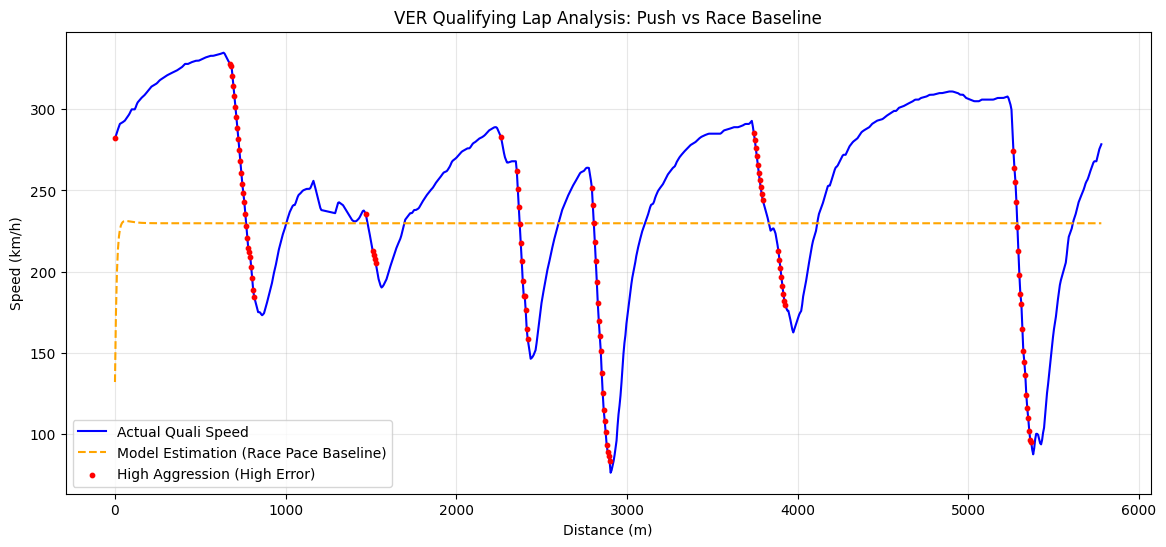

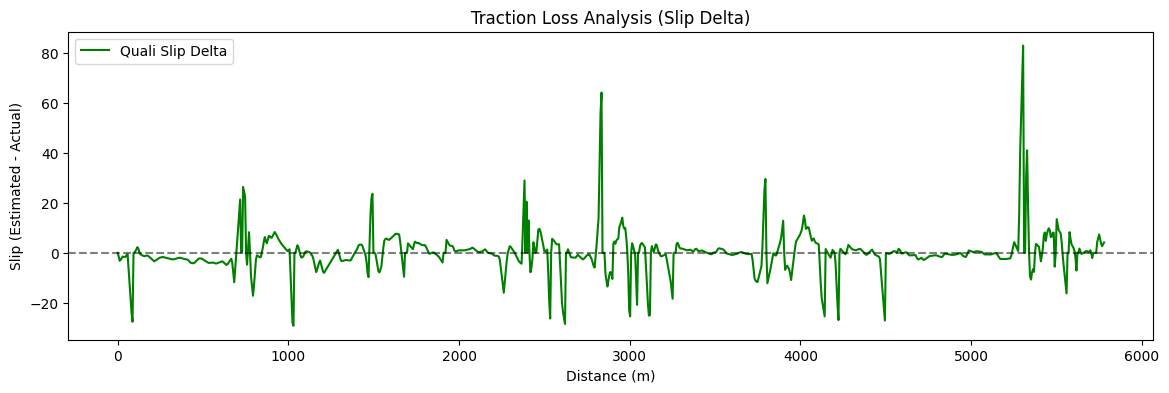

In [32]:
plt.figure(figsize=(14, 6))

# 1. 속도 비교
plt.plot(original_df['Distance'], original_df['Speed'], label='Actual Quali Speed', color='blue', linewidth=1.5)
plt.plot(original_df['Distance'], original_df['Reconstructed_Speed'], label='Model Estimation (Race Pace Baseline)', color='orange', linestyle='--', linewidth=1.5)

# 2. 차이가 큰 구간 강조 (Anomaly Score)
# 에러가 상위 10%인 구간을 붉게 칠함
threshold = np.percentile(original_df['Anomaly_Score'], 90)
mask = original_df['Anomaly_Score'] > threshold

# fill_between을 위해 불연속 구간 처리 필요하지만, 간단히 scatter로 표시
plt.scatter(original_df.loc[mask, 'Distance'], original_df.loc[mask, 'Speed'], 
            color='red', s=10, label='High Aggression (High Error)', zorder=5)

plt.title(f"{driver_code} Qualifying Lap Analysis: Push vs Race Baseline")
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 추가: SLIP_DELTA 분석 ---
# 퀄리파잉에서 타이어를 얼마나 더 미끄러뜨리며 탔는지 확인
plt.figure(figsize=(14, 4))
plt.plot(original_df['Distance'], original_df['SLIP_DELTA'], label='Quali Slip Delta', color='green')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Traction Loss Analysis (Slip Delta)")
plt.ylabel("Slip (Estimated - Actual)")
plt.xlabel("Distance (m)")
plt.legend()
plt.show()

>>> 1. Training Sample Check (Sanity Check)


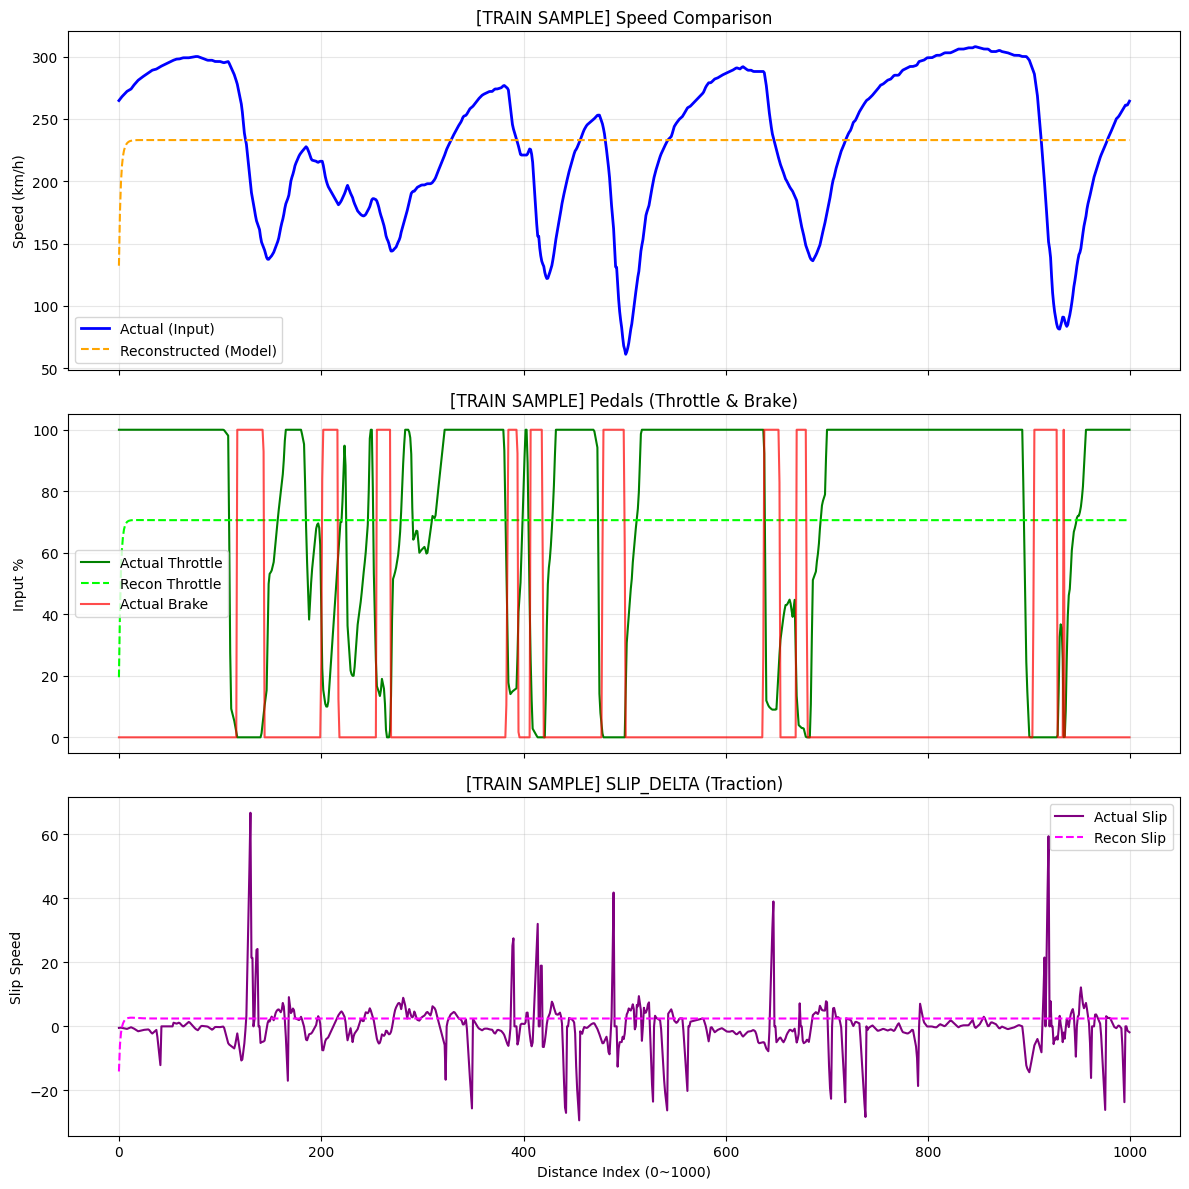


>>> 2. Qualifying Sample Check (Inference)


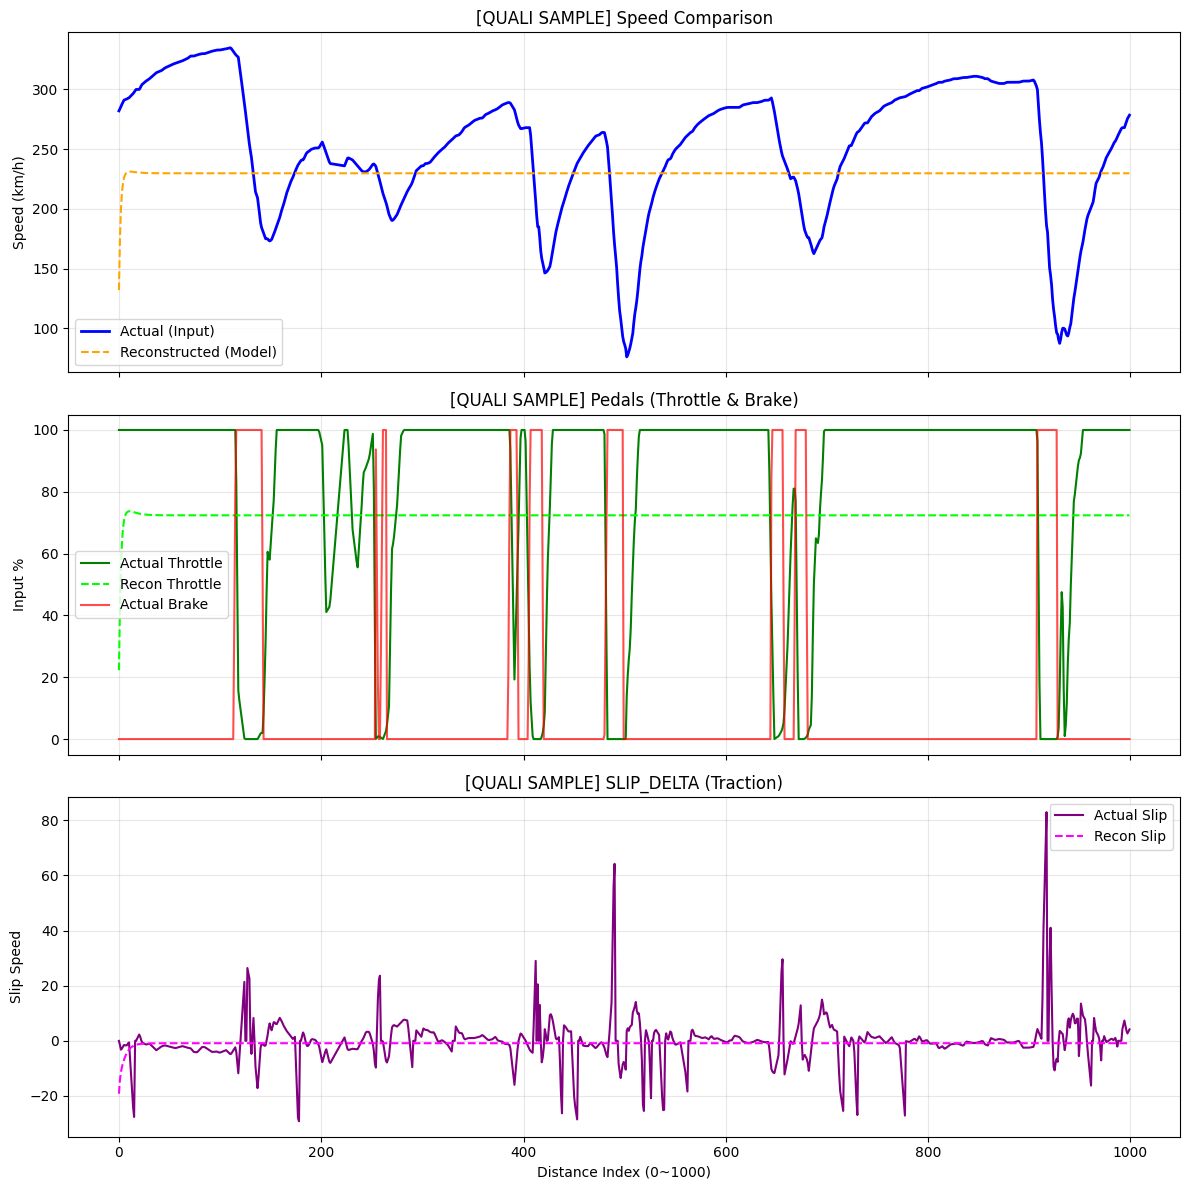

In [33]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd

def visualize_comparison(original, reconstructed, feature_names, title, scaler=None):
    """
    원본과 복원된 데이터를 시각화하는 함수 (역스케일링 포함)
    """
    # 1. 역스케일링 (Inverse Scaling)을 통해 보기 편한 원래 단위로 변환
    if scaler:
        # 2차원 배열로 변환 (TimeSteps, Features)
        orig_2d = original
        recon_2d = reconstructed
        
        # 스케일러가 학습된 컬럼 수와 맞는지 확인
        if orig_2d.shape[1] == len(feature_names):
            orig_inv = scaler.inverse_transform(orig_2d)
            recon_inv = scaler.inverse_transform(recon_2d)
        else:
            print("Warning: Feature dimension mismatch. Plotting scaled values.")
            orig_inv, recon_inv = orig_2d, recon_2d
    else:
        orig_inv, recon_inv = original, reconstructed

    # 데이터프레임 변환 (편의상)
    df_orig = pd.DataFrame(orig_inv, columns=feature_names)
    df_recon = pd.DataFrame(recon_inv, columns=feature_names)
    
    # 2. 주요 피처 시각화 (Speed, RPM, SLIP_DELTA)
    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # [Speed]
    axes[0].plot(df_orig['Speed'], label='Actual (Input)', color='blue', linewidth=2)
    axes[0].plot(df_recon['Speed'], label='Reconstructed (Model)', color='orange', linestyle='--')
    axes[0].set_title(f"[{title}] Speed Comparison")
    axes[0].set_ylabel("Speed (km/h)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # [Throttle & Brake] - 조작 패턴 확인
    axes[1].plot(df_orig['Throttle'], label='Actual Throttle', color='green')
    axes[1].plot(df_recon['Throttle'], label='Recon Throttle', color='lime', linestyle='--')
    axes[1].plot(df_orig['Brake'] * 100, label='Actual Brake', color='red', alpha=0.7) # Brake는 0~1이므로 증폭
    axes[1].set_title(f"[{title}] Pedals (Throttle & Brake)")
    axes[1].set_ylabel("Input %")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # [SLIP_DELTA] - 미세 컨트롤 확인
    axes[2].plot(df_orig['SLIP_DELTA'], label='Actual Slip', color='purple')
    axes[2].plot(df_recon['SLIP_DELTA'], label='Recon Slip', color='magenta', linestyle='--')
    axes[2].set_title(f"[{title}] SLIP_DELTA (Traction)")
    axes[2].set_ylabel("Slip Speed")
    axes[2].set_xlabel("Distance Index (0~1000)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- 1. 학습 데이터 중 하나 꺼내오기 (Train Sample) ---
# train_loader에서 배치를 하나 꺼냄
data_iter = iter(train_loader)
train_batch, _ = next(data_iter)

# 첫 번째 샘플 선택 (Batch, Seq, Feat) -> (Seq, Feat)
train_sample_tensor = train_batch[0].unsqueeze(0).to(device) # (1, 1000, 12)

# 모델 추론
model.eval()
with torch.no_grad():
    train_recon_tensor = model(train_sample_tensor)

# Numpy 변환
train_orig_np = train_sample_tensor.squeeze(0).cpu().numpy()
train_recon_np = train_recon_tensor.squeeze(0).cpu().numpy()

# 시각화 실행 (학습 데이터)
print(">>> 1. Training Sample Check (Sanity Check)")
visualize_comparison(train_orig_np, train_recon_np, feature_cols, "TRAIN SAMPLE", scaler)


# --- 2. 퀄리파잉 데이터 꺼내오기 (Quali Sample) ---
# 이전 단계에서 준비한 input_tensor (베르스타펜 퀄리파잉 랩) 사용
# input_tensor가 (1, 1000, 12) 형태라고 가정
if 'input_tensor' in locals():
    with torch.no_grad():
        quali_recon_tensor = model(input_tensor)

    quali_orig_np = input_tensor.squeeze(0).cpu().numpy()
    quali_recon_np = quali_recon_tensor.squeeze(0).cpu().numpy()

    print("\n>>> 2. Qualifying Sample Check (Inference)")
    visualize_comparison(quali_orig_np, quali_recon_np, feature_cols, "QUALI SAMPLE", scaler)
else:
    print("Qualifying input_tensor not found. Please run the previous data prep code.")

In [ ]:
import joblib
import os

# 저장할 경로 설정
SAVE_DIR = 'models'
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, 'f1_lstm_autoencoder_v1.pth')
SCALER_PATH = os.path.join(SAVE_DIR, 'f1_scaler_v1.pkl')

# 1. 모델 체크포인트 딕셔너리 생성
# 나중에 모델을 다시 빌드할 때 필요한 정보(input size 등)를 'config'에 담습니다.
checkpoint = {
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': avg_loss,
    'config': {
        'seq_len': DIST_POINTS,      # 200
        'n_features': len(feature_cols), # Feature 개수
        'embedding_dim': 128         # 히든 레이어 크기
    }
}

# 2. 모델 및 학습 정보 저장 (PyTorch)
torch.save(checkpoint, MODEL_PATH)
print(f"Model checkpoint saved at: {MODEL_PATH}")

# 3. 스케일러 저장 (Scikit-Learn) -> 매우 중요!
# 이걸 안 하면 나중에 새 데이터를 0~1로 똑같이 못 바꿉니다.
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler saved at: {SCALER_PATH}")

Model checkpoint saved at: models\f1_lstm_autoencoder_v1.pth
Scaler saved at: models\f1_scaler_v1.pkl


In [ ]:
import torch
import joblib
import torch.nn as nn

# --- 0. 모델 클래스 정의 (저장했던 코드와 동일해야 함) ---
class LSTMAutoencoder_v1(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=128):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.encoder_lstm = nn.LSTM(n_features, embedding_dim, batch_first=True)
        self.decoder_lstm = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        x_repeated = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)
        decoder_output, _ = self.decoder_lstm(x_repeated)
        x_reconstructed = self.output_layer(decoder_output)
        return x_reconstructed

# --- 1. 파일 경로 설정 ---
SAVE_DIR = 'saved_models'
MODEL_PATH = os.path.join(SAVE_DIR, 'f1_lstm_autoencoder_v1.pth')
SCALER_PATH = os.path.join(SAVE_DIR, 'f1_scaler_v1.pkl')

# --- 2. 불러오기 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# (1) 스케일러 로드
loaded_scaler = joblib.load(SCALER_PATH)
print("Scaler loaded.")

# (2) 체크포인트 로드
checkpoint = torch.load(MODEL_PATH, map_location=device)

# (3) Config를 이용해 모델 구조 초기화 (하드코딩 방지)
config = checkpoint['config']
loaded_model = LSTMAutoencoder(
    seq_len=config['seq_len'],
    n_features=config['n_features'],
    embedding_dim=config['embedding_dim']
).to(device)

# (4) 가중치 덮어씌우기
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval() # 평가 모드로 전환 (Dropout 등 비활성화)

print(f"Model loaded from epoch {checkpoint['epoch']} with loss {checkpoint['loss']:.4f}")